In [2]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [3]:
import sqlite3
import pandas as pd
DATABASE_NAME = 'odds.db'
#SOURCE_DB = r'C:\Users\rfo7799\Downloads\odds.db'

conn = sqlite3.connect(DATABASE_NAME)
table_name = 'player_props'
prop_df = pd.read_sql(f"""
                 SELECT * FROM {table_name} WHERE market_type = 'player_pass_tds'
                 --AND lower(event_name) like '%tit%'
                 """, conn)
#prop_df


In [4]:
#years = [2022, 2023, 2024, 2025]
#pbp = nfl.import_pbp_data(years=years, downcast=True)
#season = nfl.import_seasonal_data(years=years, s_type = 'REG')
#weekly = nfl.import_weekly_data(years=years)

#print('Play by Play Shape and Sample', pbp.shape, list())
#print('Season sample:')
#print(season.head(3))
#print('Weekly sample:')
#print(weekly.head(3))

#top_pass_2024 = (
#    weekly.query("season == 2024 and season_type == 'REG' and position == 'QB'")
#    .groupby(['player_id', 'player_display_name'], as_index=False)['passing_yards']
#    .sum()
#    .sort_values('passing_yards', ascending=False)
#)

#top_pass_2024.head()



In [5]:
# Select only the relevant columns
columns = ['passer_player_name', 'game_id', 'posteam', 'defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards', 
           'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
           'passing_yards', 'cpoe', 'roof', 'surface','drive','game_seconds_remaining']

# Loading in the NFL pbp data
data = nfl.import_pbp_data(range(2010,2026), downcast=True)
data = data[columns]

# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
data = data[columns]

# Drop all rows that are not a pass
data = data[(data['play_type'] == 'pass')]

# Drop the play type column
passer_data = data.drop(columns=['play_type'])

2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.


In [6]:
# Group the data together by passer, week, season and aggregate
passer_df = passer_data.groupby(['passer_player_name', 'game_id', 'week', 'season'], as_index=False).agg(
    {'posteam' : 'first',
     'defteam' : 'first',
     'home_team' : 'first',
     'away_team' : 'first',
     'air_yards' : 'sum',
     'yards_after_catch' : 'sum',
     'epa' : 'sum',
     'complete_pass' : 'sum',
     'incomplete_pass' : 'sum',
     'interception' : 'sum',
     'qb_hit' : 'sum',
     'sack' : 'sum',
     'pass_touchdown' : 'sum',
     'passing_yards' : 'sum',
     'cpoe' : 'mean',
     'roof' : 'first',
     'surface' : 'first'
     }
)

# Create a new column that is completion percentage
passer_df['completion_percentage'] = passer_df['complete_pass'] / (passer_df['complete_pass'] + passer_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
passer_df['pass_attempts'] = passer_df['complete_pass'] + passer_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
passer_df = passer_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the passer is the home team and 0 if the passer is the away team
passer_df['home_flag'] = passer_df['home_team'] == passer_df['posteam']

passer_df = passer_df.drop(columns=['home_team','away_team'])



# Reorder the columns
#passer_df = passer_df[['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'passing_yards', 'home_flag', 'completion_percentage', 'pass_attempts',
#                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
#                        'cpoe', 'roof', 'surface','total_offense_seconds']]

In [7]:
# Assuming 'pbp' is your play-by-play DataFrame from nfl_data_py
drives = data[['game_id', 'drive', 'game_seconds_remaining', 'posteam']].copy()

# Sort the data by game and drive to ensure correct ordering
drives = drives.sort_values(by=['game_id', 'drive', 'game_seconds_remaining'], ascending=[True, True, False])

# Drop duplicates to get the start and end of each drive
drive_starts = drives.groupby(['game_id', 'drive']).first().reset_index()
drive_ends = drives.groupby(['game_id', 'drive']).last().reset_index()

# Merge the start and end times to calculate the duration
drive_durations = pd.merge(drive_starts, drive_ends, on=['game_id', 'drive', 'posteam'], suffixes=('_start', '_end'))

# Calculate the duration of each drive in seconds
drive_durations['drive_duration_seconds'] = drive_durations['game_seconds_remaining_start'] - drive_durations['game_seconds_remaining_end']

# Group by game and team to get total TOP
game_top = drive_durations.groupby(['game_id', 'posteam']).agg(
    total_top_seconds=('drive_duration_seconds', 'sum')
).reset_index()

passer_df_merged = passer_df.merge(game_top, on=['game_id', 'posteam'], how='inner')
schedule_df = pd.read_csv(r'2025_schedule.csv')
passer_df_merged = passer_df_merged.merge(schedule_df[['game_id','gameday']], on=['game_id'], how='inner')

passer_df_merged.drop('game_id', axis=1, inplace=True)
passer_df_merged.head()

,passer_player_name,week,season,posteam,defteam,air_yards,yards_after_catch,epa,interception,qb_hit,sack,pass_touchdown,passing_yards,cpoe,roof,surface,completion_percentage,pass_attempts,home_flag,total_top_seconds,gameday
0,A.Dalton,4,2025,CAR,NE,46.0,35.0,9.913806,0.0,0.0,0.0,1.0,58.0,23.370016,outdoors,fieldturf,0.833333,6.0,False,1508.0,2025-09-28
1,B.Young,4,2025,CAR,NE,153.0,95.0,-8.936443,0.0,4.0,1.0,1.0,150.0,-0.411572,outdoors,fieldturf,0.600000,30.0,False,1508.0,2025-09-28
2,D.Maye,4,2025,NE,CAR,133.0,110.0,19.275635,0.0,1.0,1.0,2.0,203.0,20.405449,outdoors,fieldturf,0.823529,17.0,True,659.0,2025-09-28
3,J.Dobbs,4,2025,NE,CAR,18.0,0.0,-0.854630,0.0,0.0,0.0,0.0,0.0,-56.359833,outdoors,fieldturf,0.000000,1.0,True,659.0,2025-09-28
4,A.Dalton,7,2025,CAR,NYJ,107.0,4.0,-2.714587,0.0,1.0,1.0,0.0,60.0,1.739164,outdoors,fieldturf,0.571429,7.0,False,1263.0,2025-10-19


In [8]:
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 'interception', 
             'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe','total_top_seconds']

passer_df = passer_df_merged.sort_values(by=['passer_player_name', 'season', 'week']).reset_index(drop=True)

for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    
    # Group by player, apply EWM (which is calculated cumulatively), and then shift
    passer_df[new_col_name] = passer_df.groupby('passer_player_name')[col]\
        .transform(lambda x: x.ewm(min_periods=1, span=10).mean().shift(1))

columns_to_drop = [col for col in ewma_cols if col != 'pass_touchdown']
# 3. Drop the non-ewma columns
passer_df = passer_df.drop(columns=columns_to_drop)

In [9]:
# Select only the relevant columns
defense_columns = ['defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards',
                   'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
                   'passing_yards', 'cpoe', 'roof', 'surface']


# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
defense_data = data[defense_columns]

# Drop the play type column
defense_data = defense_data.drop(columns=['play_type'])



# Group the data together by passer, week, season and aggregate
defense_df = defense_data.groupby(['defteam', 'week', 'season'], as_index=False).agg(
    {'home_team': 'first',
     'away_team': 'first',
     'air_yards': 'sum',
     'yards_after_catch': 'sum',
     'epa': 'sum',
     'complete_pass': 'sum',
     'incomplete_pass': 'sum',
     'interception': 'sum',
     'qb_hit': 'sum',
     'sack': 'sum',
     'pass_touchdown': 'sum',
     'passing_yards': 'sum',
     'cpoe': 'mean',
     'roof': 'first',
     'surface': 'first'
     }
)

# Create a new column that is completion percentage
defense_df['completion_percentage'] = defense_df['complete_pass'] / (defense_df['complete_pass'] + defense_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
defense_df['pass_attempts'] = defense_df['complete_pass'] + defense_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
defense_df = defense_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the defense is the home team and 0 if the defense is the away team
defense_df['home_flag'] = defense_df['home_team'] == defense_df['defteam']

# Drop the home_team and away_team columns
defense_df = defense_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
defense_df = defense_df[['defteam', 'season', 'week', 'home_flag', 'passing_yards', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                       'cpoe', 'roof', 'surface']]

In [10]:
# Create a list of columns to generate EWMA features for
ewma_cols = ['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 
             'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 'passing_yards', 'cpoe']

# Step 1: Sort the DataFrame chronologically by team, season, and week
# This is crucial for accurate time-series feature generation.
defense_df = defense_df.sort_values(by=['defteam', 'season', 'week']).reset_index(drop=True)

# Step 2: Calculate the EWMA for each feature, applying a .shift(1)
# The .shift(1) ensures the EWMA for the current week is based on data up to the PREVIOUS week.
for col in ewma_cols:
    new_col_name = f'{col}_ewma'
    defense_df[new_col_name] = defense_df.groupby('defteam')[col].transform(
        lambda x: x.ewm(min_periods=1, span=10).mean().shift(1)
    )

# Step 3: Drop the original, non-EWMA columns to prevent data leakage
defense_df = defense_df.drop(columns=ewma_cols)

In [11]:
# Merge the defense and passer dataframes together
df = passer_df.merge(defense_df, how='inner', on=['defteam', 'season', 'week', 'roof', 'surface'], suffixes=('_passer', '_defense'))
df = df[df['pass_attempts_ewma_passer'] > 5]

C:\Users\rfo7799\AppData\Local\Temp\ipykernel_35848\2845491364.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset_corr = df.corr()


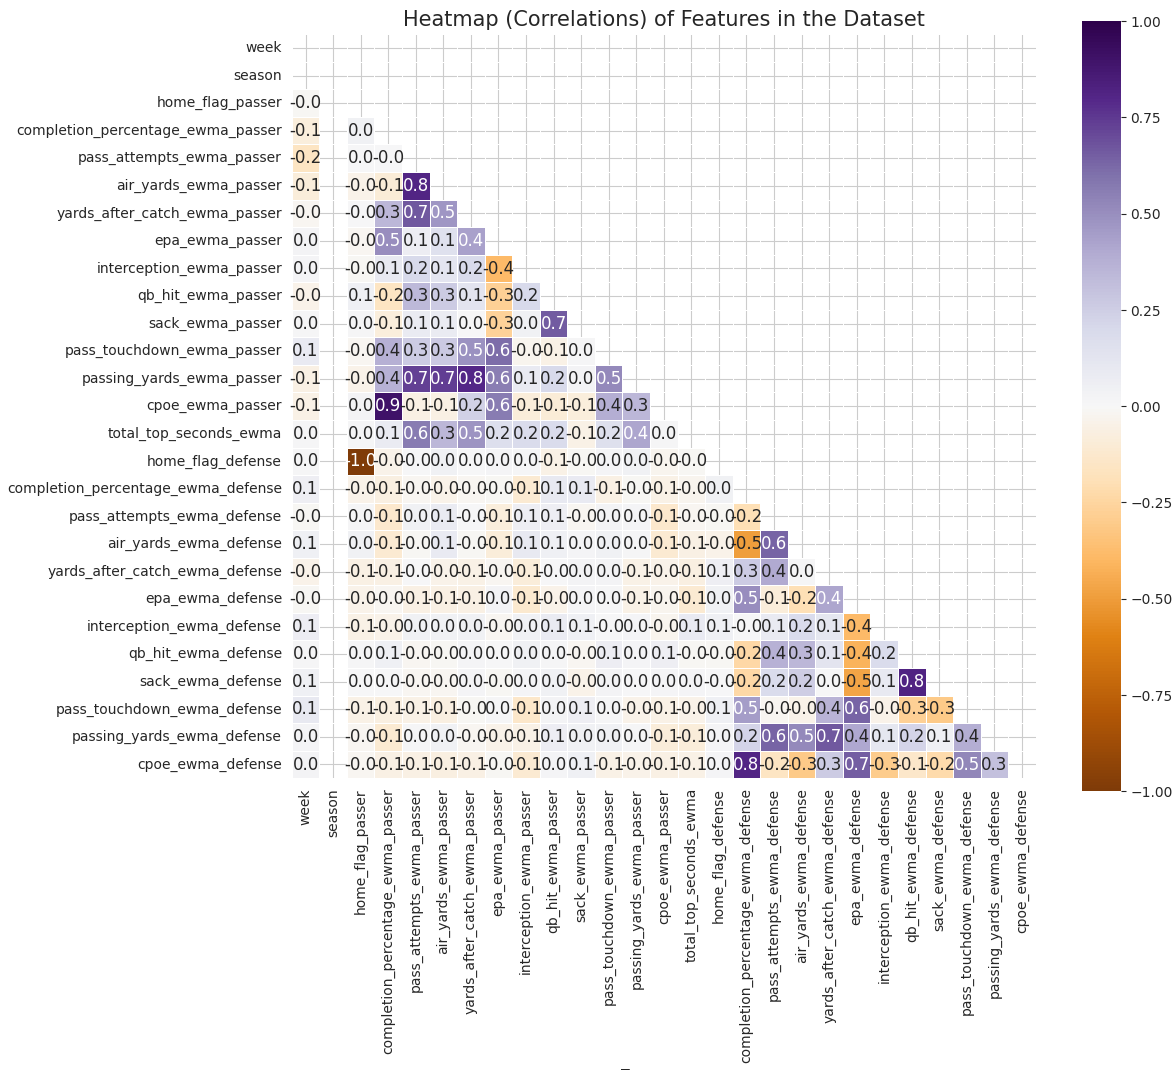

In [12]:
# Create a correlation for the dataset.
dataset_corr = df.corr()

# Drop Agent_ID from correlation dataset.
dataset_corr = dataset_corr.drop(['pass_touchdown'], axis=1)
dataset_corr = dataset_corr.drop(['pass_touchdown'], axis=0)

# Create a correlation matrix. Only bottom left corner valued.
mask = np.zeros_like(dataset_corr.round(4))
mask[np.triu_indices_from(mask)] = True

# Generate the corrleation matrix (heatmap) using Seaborn.
with sns.axes_style("whitegrid"):
    f, ax = plt.subplots(figsize=(12, 10))
    ax = sns.heatmap(dataset_corr.round(2), mask=mask, vmax=1, center=0, vmin=-1, square=True,
                     cmap='PuOr', linewidths=.5, annot=True, annot_kws={"size": 12}, fmt='.1f')
    plt.title('Heatmap (Correlations) of Features in the Dataset', fontsize=15)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Features', fontsize=15)
plt.show()

In [13]:
df.isnull().sum()
final_df = df.dropna()

In [14]:
from rapidfuzz import process, fuzz
import pandas as pd
import re

# 1. Prepare Name Lists
final_names = final_df['passer_player_name'].unique().tolist()
prop_names = prop_df['player_name'].unique().tolist()
search_choices = final_names # List to search against


def clean_name_minimal(name):
    """Standardizes names for better partial ratio matching: Lowercase, remove periods/suffixes."""
    name = name.lower()
    # Only remove the period, keep the initial separate (e.g., 'J.Hurts' -> 'j hurts')
    name = name.replace('.', ' ') 
    # Remove common suffixes
    name = re.sub(r'\s+(jr|sr|ii|iii|iv)\.?$', '', name)
    # Remove any extra spaces created
    name = re.sub(r'\s+', ' ', name).strip()
    return name


# 2. Create the Cleaned Search List and a Map to Retrieve Original Names
# NOTE: We clean prop_names (the queries) but keep final_names (the choices) as they are for the original map
cleaned_choices = [clean_name_minimal(n) for n in search_choices]

# Map from CLEANED final_name back to ORIGINAL final_name (for merge key)
clean_to_original_map = {clean_name_minimal(n): n for n in final_names}


# 3. Perform the Fuzzy Matching and Build the Match List (for ALL names)
matched_names = []
# partial_ratio requires a lower threshold than token_set, try 80
SCORE_THRESHOLD = 80

for name_prop in prop_names:
    # Clean the current name_prop for the query
    cleaned_query = clean_name_minimal(name_prop)

    best_match = process.extractOne(
        query=cleaned_query,
        choices=cleaned_choices,
        # --- KEY CHANGE: Use partial_ratio ---
        scorer=fuzz.partial_ratio,
        score_cutoff=SCORE_THRESHOLD
    )

    if best_match:
        # best_match is (cleaned_match, score, index)
        cleaned_match_name = best_match[0]
        score = best_match[1]
        
        # Get the original (uncleaned) name from final_df using the map
        original_final_name = clean_to_original_map.get(cleaned_match_name)

        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': original_final_name,
            'similarity_score': score
        })
    else:
        # No match found above the threshold
        matched_names.append({
            'prop_name': name_prop,
            'final_name_match': None,
            'similarity_score': 0.0
        })

# 4. Create Match DataFrame and Map for Merging
match_df = pd.DataFrame(matched_names)

# Display sample results
print("--- Sample Name Matches (prop_df -> final_df) ---")
print(match_df[['prop_name', 'final_name_match', 'similarity_score']].sort_values(by='similarity_score', ascending=False))
print("-" * 50)
print("\n--- Unmatched Players (Score < {}) ---".format(SCORE_THRESHOLD))
print(match_df[match_df['final_name_match'].isna()])


# 5. Perform the Merge
# Create the map from prop_name (full name) to final_name (abbreviated name)
valid_matches = match_df.dropna(subset=['final_name_match'])
name_map = valid_matches.set_index('prop_name')['final_name_match'].to_dict()

# Create the common key column in prop_df using the map
prop_df['passer_player_name'] = prop_df['player_name'].map(name_map)
prop_df['gameday'] = pd.to_datetime(prop_df['event_commence_time']).dt.strftime('%Y-%m-%d')
# Merge the DataFrames on the newly created common key
merged_df = final_df.merge(
    prop_df.drop(columns=['player_name','outcome_type']).drop_duplicates(), # Drop the redundant name column from prop_df
    on=['passer_player_name','gameday'],
    how='left'
)

print("\n✅ Merge complete.")
print(merged_df)
merged_df.dropna(subset='sport_key', inplace=True)

--- Sample Name Matches (prop_df -> final_df) ---
            prop_name final_name_match  similarity_score
34      J.J. McCarthy       J.McCarthy        100.000000
14     Tua Tagovailoa     T.Tagovailoa         95.652174
19     Baker Mayfield       B.Mayfield         94.736842
9    Matthew Stafford       M.Stafford         94.736842
25     Caleb Williams       C.Williams         94.736842
11       Dak Prescott       D.Prescott         94.736842
37    Jacoby Brissett       J.Brissett         94.736842
5     Trevor Lawrence       T.Lawrence         94.736842
7     Spencer Rattler        S.Rattler         94.117647
4         Sam Darnold        S.Darnold         94.117647
33      Lamar Jackson        L.Jackson         94.117647
32     Marcus Mariota        M.Mariota         94.117647
26     Jayden Daniels        J.Daniels         94.117647
15     Justin Herbert        J.Herbert         94.117647
22    Patrick Mahomes        P.Mahomes         94.117647
13      Aaron Rodgers        A.Rodgers

C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname EDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname EST identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [15]:
merged_df.drop(columns=['event_id','event_name','sport_key','event_commence_time','updated_dttm'], axis=1, inplace=True)

In [16]:
# Identify categorical columns to be encoded
categorical_cols = ['passer_player_name', 'posteam', 'defteam', 'roof', 'surface']

# Perform one-hot encoding
final_df = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=True)
final_df.drop(['gameday','market_type'], axis=1, inplace=True)
final_df['Status'] = (final_df['pass_touchdown'] > final_df['point_value']).astype(int)

In [17]:
list(final_df.columns)

['week',
 'season',
 'pass_touchdown',
 'home_flag_passer',
 'completion_percentage_ewma_passer',
 'pass_attempts_ewma_passer',
 'air_yards_ewma_passer',
 'yards_after_catch_ewma_passer',
 'epa_ewma_passer',
 'interception_ewma_passer',
 'qb_hit_ewma_passer',
 'sack_ewma_passer',
 'pass_touchdown_ewma_passer',
 'passing_yards_ewma_passer',
 'cpoe_ewma_passer',
 'total_top_seconds_ewma',
 'home_flag_defense',
 'completion_percentage_ewma_defense',
 'pass_attempts_ewma_defense',
 'air_yards_ewma_defense',
 'yards_after_catch_ewma_defense',
 'epa_ewma_defense',
 'interception_ewma_defense',
 'qb_hit_ewma_defense',
 'sack_ewma_defense',
 'pass_touchdown_ewma_defense',
 'passing_yards_ewma_defense',
 'cpoe_ewma_defense',
 'point_value',
 'odds',
 'passer_player_name_A.Rodgers',
 'passer_player_name_B.Mayfield',
 'passer_player_name_B.Nix',
 'passer_player_name_B.Young',
 'passer_player_name_C.Stroud',
 'passer_player_name_C.Ward',
 'passer_player_name_C.Wentz',
 'passer_player_name_C.Willia

In [18]:
X = final_df.drop(['pass_touchdown','week','season','point_value','Status'], axis=1)  # Features
y = final_df['Status']              # Target

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_[0]})
print(coef_df.sort_values(by='Coefficient', ascending=False).head())

                Feature  Coefficient
24    cpoe_ewma_defense     0.335579
7    qb_hit_ewma_passer     0.143316
127   surface_fieldturf     0.093608
8      sack_ewma_passer     0.043374
119          defteam_SF     0.040721


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 87, number of negative: 82
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1196
[LightGBM] [Info] Number of data points in the train set: 169, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514793 -> initscore=0.059189
[LightGBM] [Info] Start training from score 0.059189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Classification Model Comparison ---
              Accuracy  Precision    Recall  F1-Score   AUC-ROC
RandomForest   1.00000   1.000000  1.000000  1.000000  1.000000
LightGBM       1.00000   1.000000  1.000000  1.000000  1.000000
XGBoost        1.00000   1.000000  1.000000  1.000000  1.000000
LR             0.55814   0.681818  0.555556  0.612245  0.638889

The best performing model based on AUC-ROC is: RandomForest


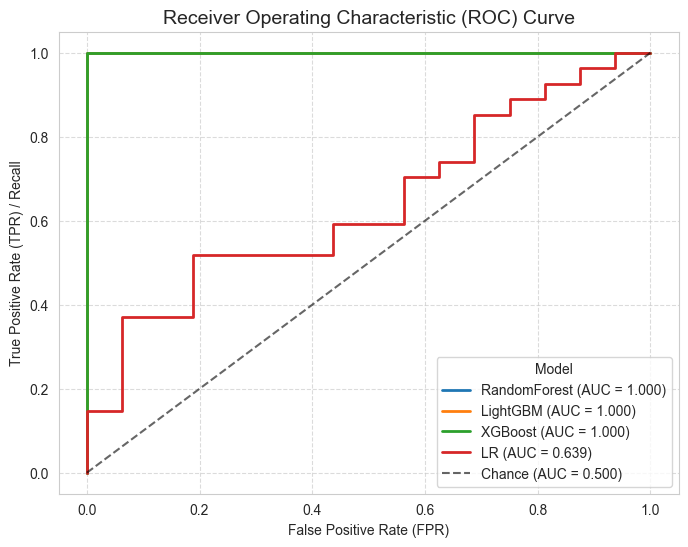

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve
)

# Instantiate the models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LR': LogisticRegression(random_state=42),
}

roc_data = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # 1. Get predicted class labels
    y_pred = model.predict(X_test)
    
    # 2. Get predicted probabilities for the positive class (required for AUC-ROC and ROC Curve)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback (though all models above have predict_proba)
        y_proba = y_pred 
    
    # Calculate classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Calculate AUC-ROC
    try:
        auc_roc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc_roc = np.nan 

    # Store metrics
    results[name] = {
        'Accuracy': accuracy, 
        'Precision': precision, 
        'Recall': recall, 
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    
    # Calculate ROC Curve points (FPR, TPR, thresholds)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_roc}


# -----------------------------------------------
# 1. Print the comparison results
# -----------------------------------------------
results_df = pd.DataFrame(results).T.sort_values(by='AUC-ROC', ascending=False)
print("--- Classification Model Comparison ---")
print(results_df)

best_model_name = results_df.index[0]
print(f"\nThe best performing model based on AUC-ROC is: {best_model_name}")

# -----------------------------------------------
# 2. Plot the AUC-ROC Curve
# -----------------------------------------------

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid") # Use a clean seaborn style

# Plot ROC curve for each model
for name, data in roc_data.items():
    plt.plot(
        data['fpr'], data['tpr'], 
        label=f"{name} (AUC = {data['auc']:.3f})", 
        linewidth=2
    )

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)', alpha=0.6)

# Customize the plot
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right', title='Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [21]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Instantiate the RandomForest model
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='neg_root_mean_squared_error',
                              n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

# Get the best model and its parameters
tuned_rf = grid_search_rf.best_estimator_
rf_best_params = grid_search_rf.best_params_
print(f"Best parameters found for RandomForest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
383 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\rfo7799\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 471, in _validate_params


Best parameters found for RandomForest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

rf_tuned_model = RandomForestClassifier(**rf_best_params, random_state=42)

rf_tuned_model.fit(X_train, y_train)
y_pred = rf_tuned_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
y_proba = rf_tuned_model.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# --- 1. ADD FEATURE IMPORTANCE SCORING ---
feature_importances_df = pd.DataFrame(
    rf_tuned_model.feature_importances_, 
    index=X_train.columns, 
    columns=['Importance'] # Only one column name at this step
)

feature_importances_df = feature_importances_df.sort_values(
    by='Importance', 
    ascending=False
).reset_index()
# Rename the columns to your requested names
feature_importances_df.columns = ['Feature', 'Importance']

# --- Print Results ---
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 0.9535
F1 Score: 0.9615
AUC-ROC: 1.0000
Confusion Matrix:
[[16  0]
 [ 2 25]]


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_35848\4232314556.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances_df[:15], x='Importance', y='Feature', palette='magma')


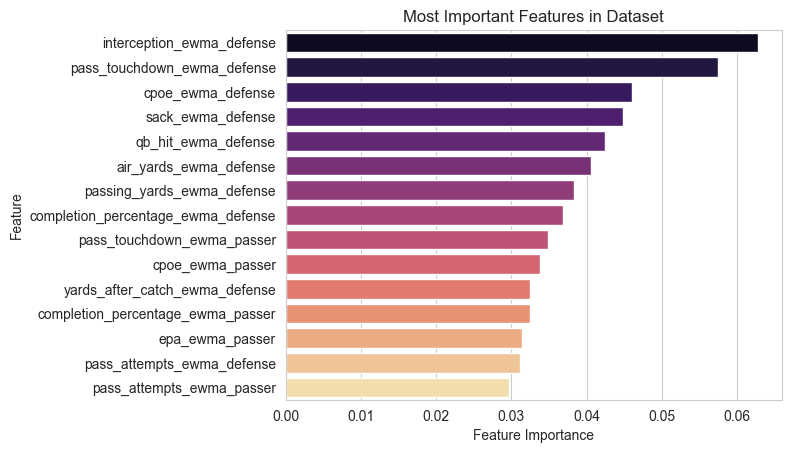

In [23]:
sns.barplot(data=feature_importances_df[:15], x='Importance', y='Feature', palette='magma')
plt.title("Most Important Features in Dataset")
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

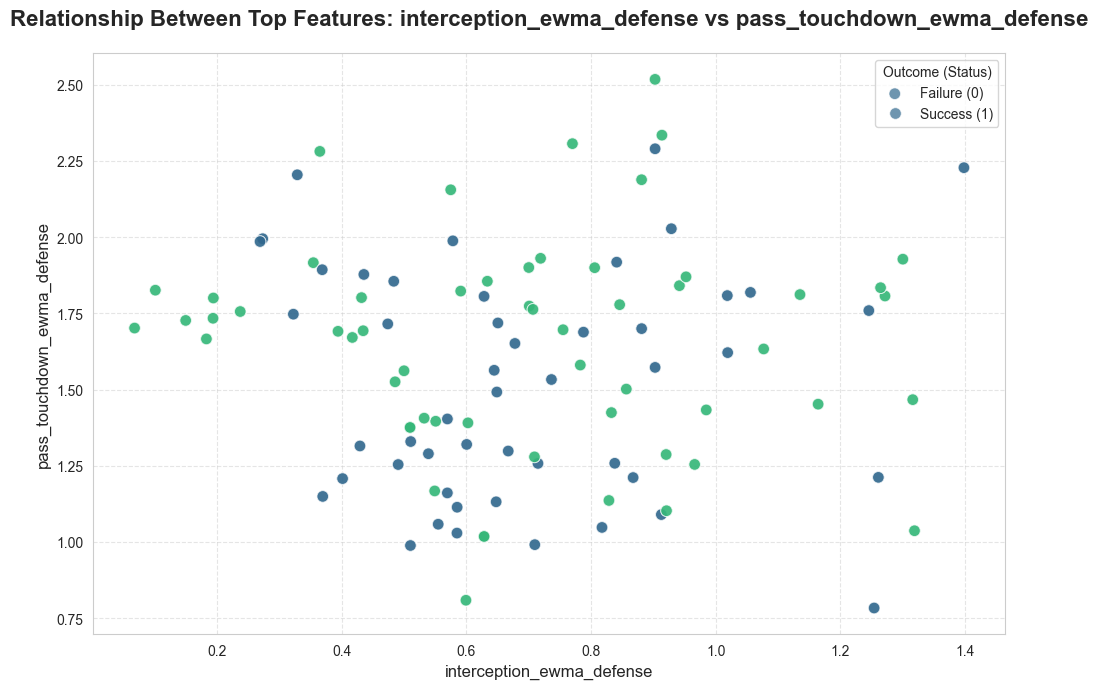

In [24]:
top_feature_1 = feature_importances_df.loc[0, 'Feature']
top_feature_2 = feature_importances_df.loc[1, 'Feature']
plt.figure(figsize=(10, 7))
sns.scatterplot(data=final_df, x=top_feature_1, y=top_feature_2, hue='Status', palette='viridis', s=70, alpha=0.7, legend='full')
plt.title(
    f'Relationship Between Top Features: {top_feature_1} vs {top_feature_2}',
    fontsize=16, 
    fontweight='bold', 
    pad=20
)
plt.xlabel(top_feature_1, fontsize=12)
plt.ylabel(top_feature_2, fontsize=12)

# 4. Enhance the appearance and legend
plt.grid(True, linestyle='--', alpha=0.5) # Add a light grid
plt.legend(title='Outcome (Status)', loc='best', labels=['Failure (0)', 'Success (1)'])

plt.tight_layout()
plt.show()


Explained variance ratio by PC1 and PC2: 0.3356


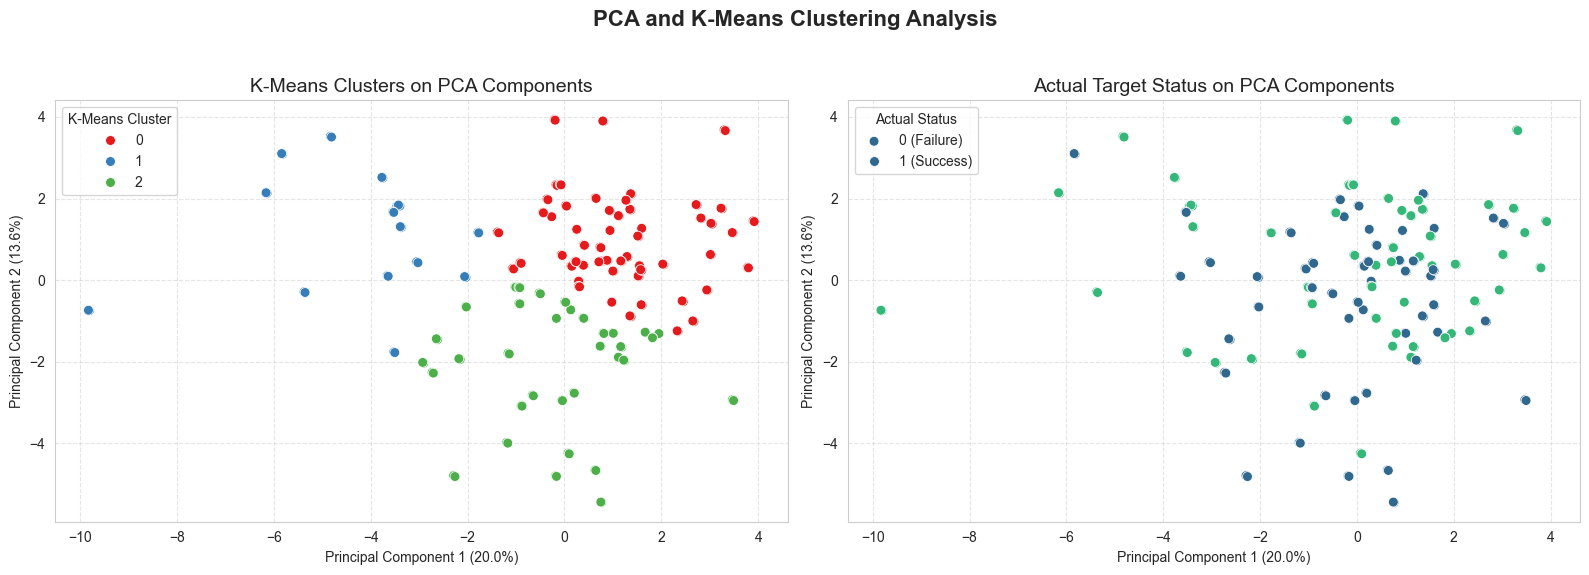

In [25]:
analysis_df = merged_df.copy()
analysis_df['Status'] = (analysis_df['pass_touchdown'] > analysis_df['point_value']).astype(int)
cols = analysis_df.select_dtypes(exclude='object')
cols = cols.drop(['week','season','home_flag_defense'], axis=1)
cols = cols.columns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = analysis_df[cols].drop(['Status'], axis=1)
y = analysis_df['Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = principal_components, 
                      columns = ['PC1', 'PC2'],
                      index=X.index)

explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"\nExplained variance ratio by PC1 and PC2: {explained_variance:.4f}")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df['Cluster_Label'] = kmeans.fit_predict(pca_df[['PC1', 'PC2']])
pca_df['Actual_Status'] = y.loc[pca_df.index].astype(str)

plt.figure(figsize=(16, 6))

# Plot 1: K-Means Clusters
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=pca_df, 
    hue='Cluster_Label', 
    palette='Set1', 
    s=50
)
plt.title('K-Means Clusters on PCA Components', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='K-Means Cluster', loc='best')

# Plot 2: Actual Status for Comparison
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=pca_df, 
    hue='Actual_Status', 
    palette='viridis', 
    s=50
)
plt.title('Actual Target Status on PCA Components', fontsize=14)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Actual Status', labels=['0 (Failure)', '1 (Success)'], loc='best')

plt.suptitle('PCA and K-Means Clustering Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


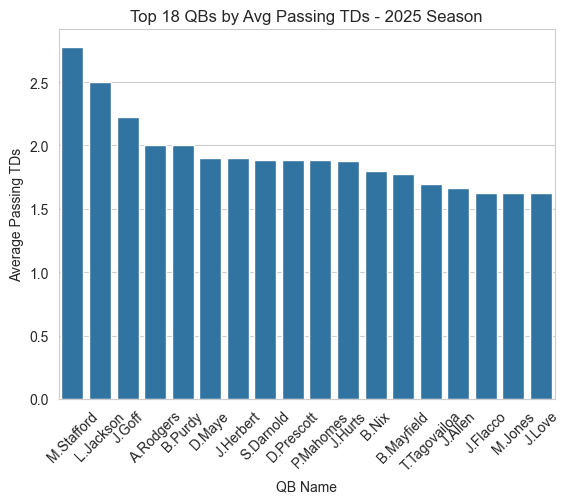

In [26]:
top_n = 18
min_entries = 3
target_season = 2025
season_df = passer_df[passer_df['season'] == target_season].copy()
qb_stats = season_df.groupby('passer_player_name').agg(
    Avg_Passing_TDs=('pass_touchdown', 'mean'), 
    Game_Count=('pass_touchdown', 'count') # Use a distinct name for the count column
).reset_index() # Promote passer_player_name from index to column
qb_stats
sns.barplot(data=qb_stats.sort_values(by='Avg_Passing_TDs', ascending=False)[:top_n].dropna(), x='passer_player_name', y='Avg_Passing_TDs')
plt.xticks(rotation=45)
plt.xlabel('QB Name')
plt.ylabel('Average Passing TDs')
plt.title(f'Top {top_n} QBs by Avg Passing TDs - 2025 Season')
plt.show()

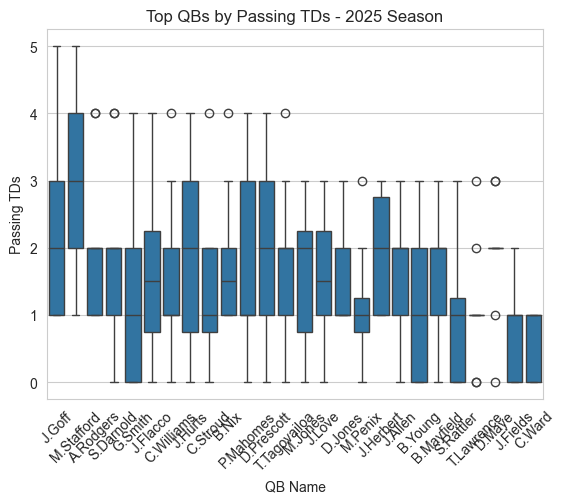

In [27]:
min_entries = passer_df[passer_df['season'] == 2025]['week'].max()-2
target_season = 2025
season_df = passer_df[passer_df['season'] == target_season][['pass_touchdown','passer_player_name']].copy().dropna(subset='pass_touchdown')
min_df = passer_df[passer_df['season'] == target_season][['pass_touchdown','passer_player_name']].copy().dropna(subset='pass_touchdown').groupby('passer_player_name')['pass_touchdown'].count().reset_index()
min_df.rename({'pass_touchdown':'count'}, axis=1, inplace=True)
season_df = season_df.merge(min_df, how='inner', on='passer_player_name')
sns.boxplot(data=season_df[season_df['count'] >= min_entries].sort_values(by='pass_touchdown', ascending=False), x='passer_player_name', y='pass_touchdown')
plt.xticks(rotation=45)
plt.xlabel('QB Name')
plt.ylabel('Passing TDs')
plt.title(f'Top QBs by Passing TDs - 2025 Season')
plt.show()

In [28]:
model = LogisticRegression(random_state=42)
model.fit(X_scaled, y)
coefs = model.coef_
coefs = model.coef_[0] # coef_ is a 2D array, extract the first (and only) row
magnitude_weights = np.abs(coefs)
objective_weights = magnitude_weights / np.sum(magnitude_weights)
weights_df = pd.DataFrame({
    'Metric': X.columns, # Use original feature names from DataFrame X
    'Raw Logit Coefficient (Beta)': coefs,
    'Objective Weight (Magnitude)': objective_weights
}).sort_values(by='Objective Weight (Magnitude)', ascending=False)

weights_df['Signed Objective Weight'] = np.where(
    # Condition: If the raw coefficient is negative
    weights_df['Raw Logit Coefficient (Beta)'] > 0,
    
    # Value if True: Multiply the magnitude by -1
    weights_df['Objective Weight (Magnitude)'] *-1,
    
    # Value if False: Keep the positive magnitude
    weights_df['Objective Weight (Magnitude)']
)
weights_df = weights_df[['Metric','Objective Weight (Magnitude)','Signed Objective Weight']]
defensive_metrics_df = weights_df[
    weights_df['Metric'].str.contains('defense', case=False, na=False)
].copy()

# Option 2: Get a list of the metric names (if you need it for external use)
def_col_names = defensive_metrics_df['Metric'].tolist()

print("--- Filtered Defensive Weights DataFrame ---")
print(defensive_metrics_df)
print("\nList of Filtered Metric Names:")
print(def_col_names)

merged_df[def_col_names + ['defteam']]
ranking_df = merged_df[def_col_names + ['defteam']].copy()
defense_performance = ranking_df.groupby('defteam')[def_col_names].mean().reset_index()

weight_map = defensive_metrics_df.set_index('Metric')['Signed Objective Weight'].to_dict()

scaler = StandardScaler()
X_agg = defense_performance[def_col_names]
X_agg_scaled = scaler.fit_transform(X_agg)
scaled_df = pd.DataFrame(
    X_agg_scaled, 
    columns=[f'{col}_ZScore' for col in def_col_names], 
    index=defense_performance.index
)
# Re-attach the defteam column
scaled_df['defteam'] = defense_performance['defteam']

scaled_df['Composite_Score'] = 0

# Apply the weighted sum using the 'Signed Objective Weight'
for metric, weight in weight_map.items():
    # Find the corresponding Z-score column name
    z_score_col = f'{metric}_ZScore'
    
    # Add the weighted score contribution
    # (Z-Score * Signed Objective Weight)
    scaled_df['Composite_Score'] += scaled_df[z_score_col] * weight

# --- STEP 4: Final Ranking ---

# Sort the teams by the composite score (Highest score is best defense)
final_ranking = scaled_df[['defteam', 'Composite_Score']].sort_values(
    by='Composite_Score', 
    ascending=False
).reset_index(drop=True)

print("\n--- 🥇 Top 10 Defensive Ranking (Composite Score) 2025 ---")
print(final_ranking.head(10))


--- Filtered Defensive Weights DataFrame ---
                                Metric  Objective Weight (Magnitude)  \
16              air_yards_ewma_defense                      0.051084   
21                   sack_ewma_defense                      0.021711   
17      yards_after_catch_ewma_defense                      0.020192   
24                   cpoe_ewma_defense                      0.009241   
15          pass_attempts_ewma_defense                      0.008639   
22         pass_touchdown_ewma_defense                      0.008127   
18                    epa_ewma_defense                      0.006288   
19           interception_ewma_defense                      0.006250   
14  completion_percentage_ewma_defense                      0.003842   
20                 qb_hit_ewma_defense                      0.001799   
23          passing_yards_ewma_defense                      0.000854   

    Signed Objective Weight  
16                -0.051084  
21                 0.021711  


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_35848\1421839251.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = final_ranking, x='defteam', y='Composite_Score', palette='rocket')


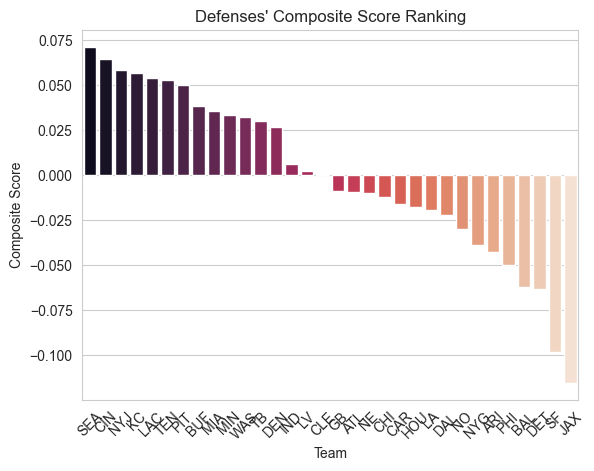

In [29]:
sns.barplot(data = final_ranking, x='defteam', y='Composite_Score', palette='rocket')
plt.title("Defenses' Composite Score Ranking")
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.ylabel('Composite Score')
plt.show()

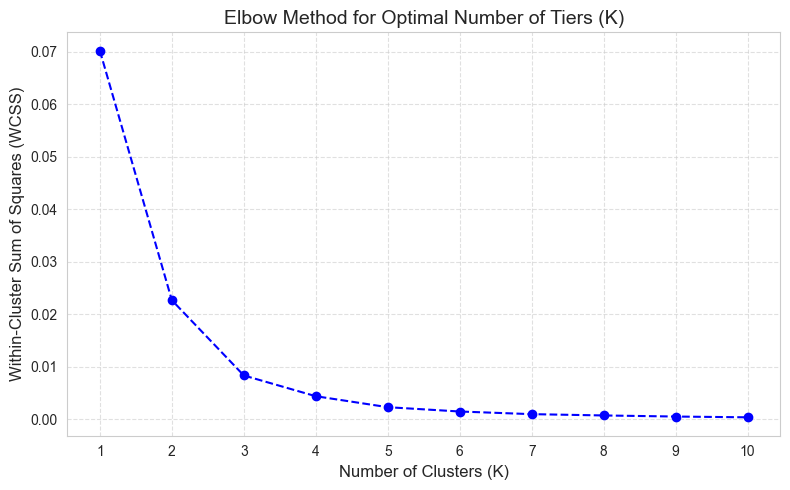

In [30]:
X_scores = final_ranking[['Composite_Score']].values

wcss = []
k_range = range(1, 11) # Test K values from 1 to 10

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X_scores)
    wcss.append(kmeans_k.inertia_) # inertia_ is the WCSS

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal Number of Tiers (K)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

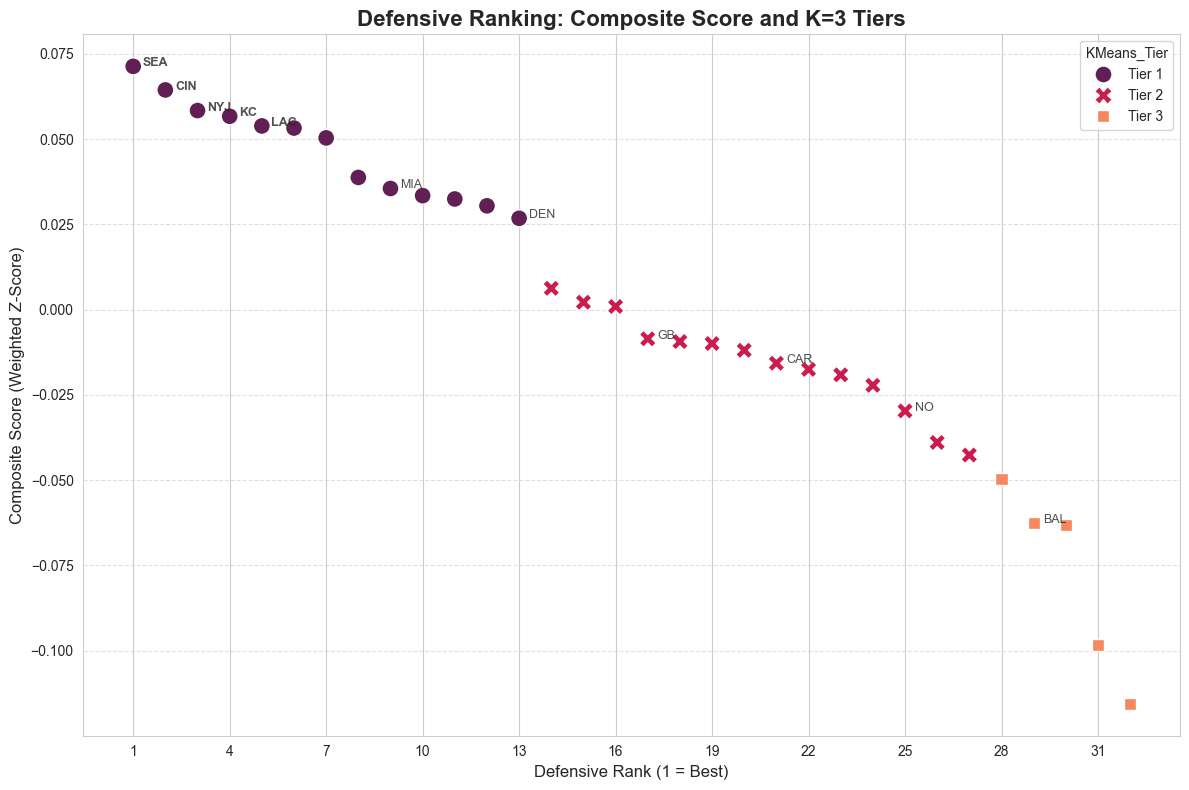

In [31]:
K = 3

X_scores = final_ranking[['Composite_Score']].values
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
final_ranking['Cluster'] = kmeans.fit_predict(X_scores)

# Map cluster numbers to sequential tier names
centroid_map = final_ranking.groupby('Cluster')['Composite_Score'].mean().sort_values(ascending=False)
tier_mapping = {cluster_id: f'Tier {i+1}' for i, cluster_id in enumerate(centroid_map.index)}
final_ranking['KMeans_Tier'] = final_ranking['Cluster'].map(tier_mapping)
final_ranking['Rank'] = final_ranking.index + 1

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=final_ranking,
    x='Rank',
    y='Composite_Score',
    hue='KMeans_Tier',
    palette='rocket',
    s=150,
    style='KMeans_Tier',
    legend='full'
)

for index, row in final_ranking.iterrows():
    # Annotate the top 5 teams and every 4th team to prevent visual clutter
    if row['Rank'] <= 5 or (row['Rank'] - 1) % 4 == 0:
        plt.annotate(
            row['defteam'],
            (row['Rank'] + 0.3, row['Composite_Score']), # Offset slightly to the right of the point
            fontsize=9,
            alpha=0.8,
            fontweight='bold' if row['Rank'] <= 5 else 'normal'
        )

# Set up the plot title and labels
plt.title(f'Defensive Ranking: Composite Score and K={K} Tiers', fontsize=16, fontweight='bold')
plt.xlabel('Defensive Rank (1 = Best)', fontsize=12)
plt.ylabel('Composite Score (Weighted Z-Score)', fontsize=12)
plt.xticks(range(1, final_ranking['Rank'].max() + 1, 3))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
import joblib
# Save the tuned LGBM model for rushing yards
#joblib.dump(rf_tuned_model, 'rf_passing_model.joblib')

# Save the tuned Random Forest model for rushing yards
joblib.dump(rf_tuned_model, 'rf_pass_tds_model.joblib')
X_train.to_csv(r'model_trained_on_tds_data.csv')

print("All optimal models have been saved to disk.")

All optimal models have been saved to disk.
